---
title: "Site Closure Problems"
image: image.png
toc: true
execute: 
  enabled: true
---

Often we may find ourselves with a set of sites where we are required to close one or more of them due to budget or other constraints, but wish to do this in a way that will minimize the impact on users. 

This is an easy thing to do with lokigi. 

To start with, we will set up our problem as usual. 

For our site file, we simply load in a file containing the positions of all of our existing sites, and provide a travel matrix of travel times from each region to those sites. 

Here, we've also provided a region geometry layer to support plotting. 

In [1]:
from lokigi.site import SiteProblem

problem_public_transport_extended = SiteProblem()

problem_public_transport_extended.add_sites(
    "../../../sample_data/devon_mius.geojson",
    candidate_id_col="Facility_Name"
    )

problem_public_transport_extended.add_region_geometry_layer(
    "https://github.com/hsma-programme/h6_3c_interactive_plots_travel/raw/main/h6_3c_interactive_plots_travel/example_code/LSOA_2011_Boundaries_Super_Generalised_Clipped_BSC_EW_V4.geojson",
    common_col="LSOA11NM"
    )

problem_public_transport_extended.add_travel_matrix(
    travel_matrix_df="../../../sample_data/devon_miu_travel_matrix_public_transport_extended.csv",
    source_col="from_id",
    unit="minutes",
    )


Let's quickly remind ourselves of the sites in this case. 

In [2]:
problem_public_transport_extended.show_sites()

,canonical_site_index,Facility_Name,Latitude,Longitude,geometry
0,0,North Devon District Hospital,51.09217,-4.05043,POINT (256506.101 134540.134)
1,1,Honiton Hospital,50.79492,-3.18659,POINT (316466.043 100155.33)
2,2,Tiverton & District Hospital,50.90933,-3.49308,POINT (295122.857 113268.884)
3,3,Exmouth Minor Injury Unit,50.62083,-3.40198,POINT (300919.29 81063.23)
4,4,Victoria Hospital (Sidmouth),50.68161,-3.23966,POINT (312514.661 87617.001)
5,5,Newton Abbot Community Hospital,50.53926,-3.61224,POINT (285848.833 72295.946)
6,6,Totnes Community Hospital,50.43283,-3.68406,POINT (280491.309 60575.271)
7,7,NHS Walk in Centre (Exeter),50.72658,-3.52521,POINT (292444.533 92994.08)
8,8,Tavistock Hospital,50.54708,-4.15376,POINT (247503.629 74139.474)
9,9,South Hams Hospital (Kingsbridge),50.28929,-3.78143,POINT (273194.03 44777.085)


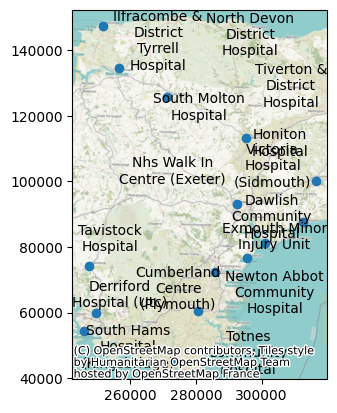

In [3]:
problem_public_transport_extended.plot_sites()

Effectively, we have 15 sites. Let's imagine that we've been told we need to choose two to close. 

We will simply pass in a p that is lower than the number of existing sites. 

In [4]:
sites_to_close = 2

n_existing_sites = len(problem_public_transport_extended.show_sites())

n_sites_remaining = n_existing_sites - sites_to_close

solution_greedy_public_transport_extended = problem_public_transport_extended.solve(
    p=n_sites_remaining,
    search_strategy="greedy",
    threshold_for_coverage=60
    )

C:\lokigi\lokigi\site.py:1414: UserWarning: No demand data was provided. Demand from all regions has been assumed to be equal.If you wish to override this, run .add_demand() to add your site dataframe before running .solve() again.You can use the .show_demand_format() to see the expected format beforehand.
  warn(


  0%|          | 0/13 [00:00<?, ?it/s]

Best combination for 1 sites: [7]
Best combination for 2 sites: [7, 11]
Best combination for 3 sites: [0, 7, 11]
Best combination for 4 sites: [0, 6, 7, 11]
Best combination for 5 sites: [0, 1, 6, 7, 11]
Best combination for 6 sites: [0, 1, 5, 6, 7, 11]
Best combination for 7 sites: [0, 1, 5, 6, 7, 10, 11]
Best combination for 8 sites: [0, 1, 3, 5, 6, 7, 10, 11]
Best combination for 9 sites: [0, 1, 3, 5, 6, 7, 8, 10, 11]
Best combination for 10 sites: [0, 1, 2, 3, 5, 6, 7, 8, 10, 11]
Best combination for 11 sites: [0, 1, 2, 3, 5, 6, 7, 8, 10, 11, 12]
Best combination for 12 sites: [0, 1, 2, 3, 5, 6, 7, 8, 10, 11, 12, 14]
Best combination for 13 sites: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 14]


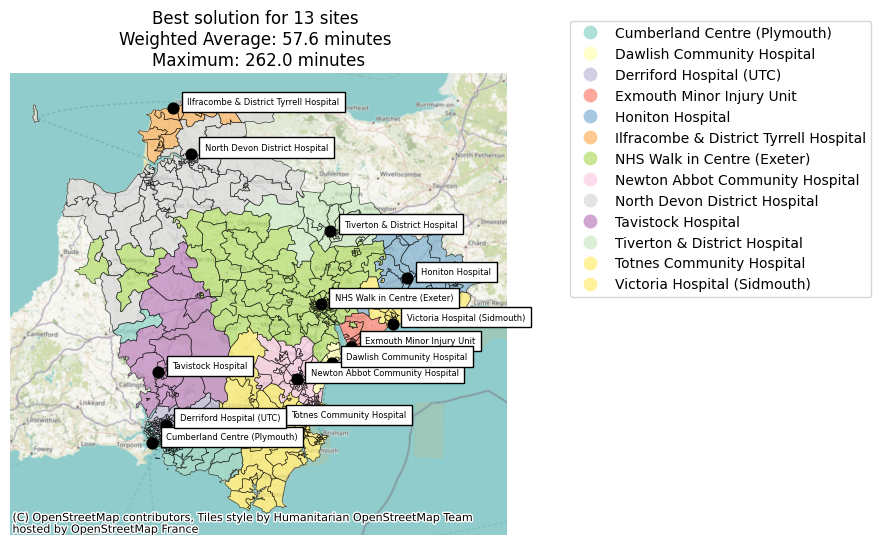

In [5]:
fig = solution_greedy_public_transport_extended.plot_best_combination(
    unchosen_site_colour="magenta",
    plot_site_allocation=True,
    legend_loc="lower right",
    show_all_locations=False,
    cmap="Set3",
    )
fig;

In [6]:
solution_greedy_public_transport_extended.show_solutions()

,site_names,site_indices,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,proportion_within_coverage_threshold,problem_df
0,"[North Devon District Hospital, Honiton Hospit...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 14]",60,57.65,57.65,98.4,262.0,0.62,from_id from_id_x North D...


### Brute force

In fact, when you only want to close one or two sites, brute force (evaluating every possible combination) is often quite doable. 

In [7]:
solution_bf_public_transport_extended = problem_public_transport_extended.solve(
    p=len(problem_public_transport_extended.show_sites())-2,
    search_strategy="brute-force",
    threshold_for_coverage=60
    )

  0%|          | 0/105 [00:00<?, ?it/s]

We can see that in this case it's found a slightly better solution than our greedy solution did. 

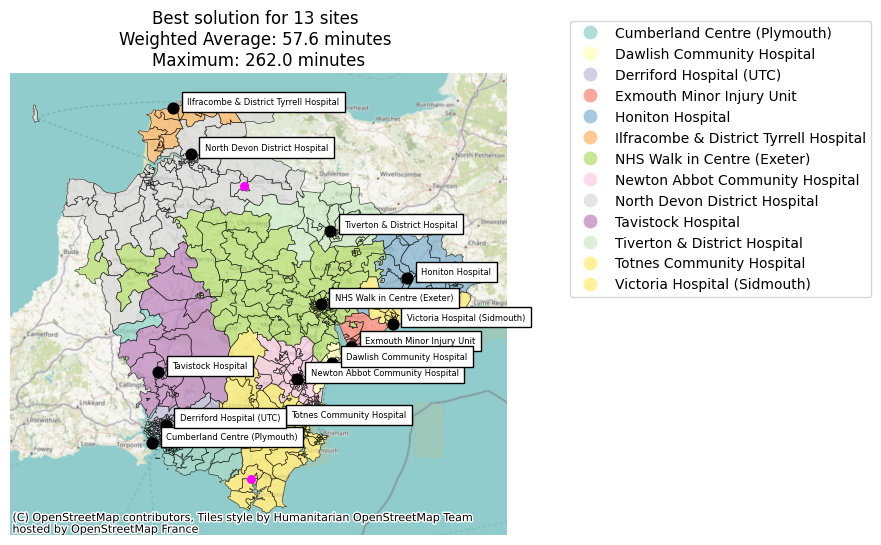

In [27]:
solution_bf_public_transport_extended.plot_best_combination(
    unchosen_site_colour="magenta",
    unchosen_site_opacity=1,
    plot_site_allocation=True,
    legend_loc="lower right",
    show_all_locations=True,
    cmap="Set3",
    title_font_size=12
    );

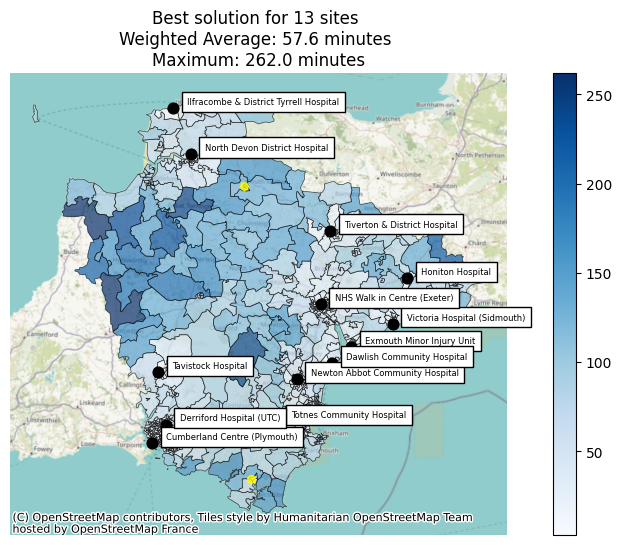

In [21]:
solution_bf_public_transport_extended.plot_best_combination(unchosen_site_colour="yellow", unchosen_site_opacity=0.8);

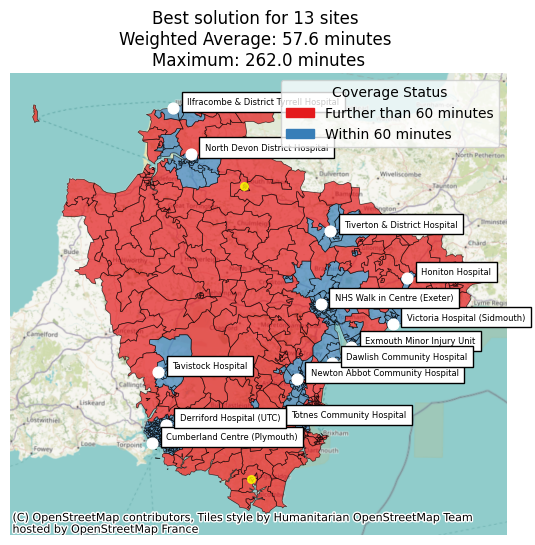

In [ ]:
solution_bf_public_transport_extended.plot_best_combination(
    plot_regions_not_meeting_threshold=True, chosen_site_colour="white",
    unchosen_site_colour="yellow", unchosen_site_opacity=0.8
    );

In [17]:
solution_bf_public_transport_extended.show_solutions().head(1)

,site_names,site_indices,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,proportion_within_coverage_threshold,problem_df
0,"[North Devon District Hospital, Honiton Hospit...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 14]",60,57.65,57.65,98.4,262.0,0.62,from_id from_id_x North D...



:::{.callout-note}
Visually, it's interesting to note that in the best solution, 62% of LSOAs are within 60 minutes. Because the larger LSOAs dominate the map area, this looks worse than it is in terms of LSOA counts. While LSOAs don't contain exactly the same population as each other, it's still useful to note that the situation may not be as dire as it seems at first glance. Options like hexagonal maps provide ways of managing this. 
:::

:::{.callout-tip}
Don't forget to consider boundary effects! In our example, there's a hospital just over the border in North Cornwall, but our travel matrix only considers MIUs situated within Devon.  
:::

We can change the threshold from 60 to 90 minutes and rerun for comparison. 

  0%|          | 0/105 [00:00<?, ?it/s]

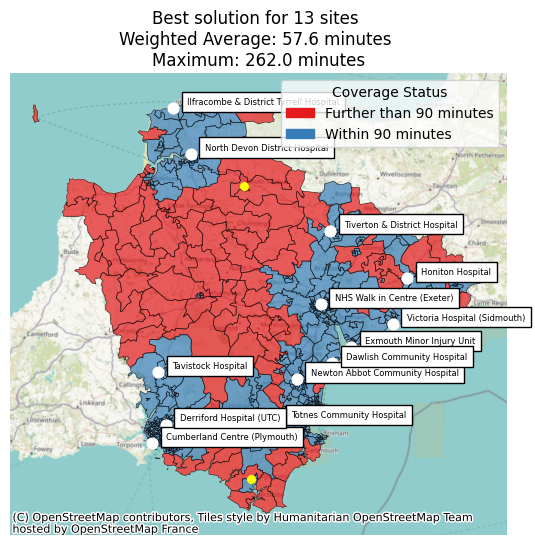

In [ ]:
solution_bf_public_transport_extended_higher_threshold = problem_public_transport_extended.solve(
    p=len(problem_public_transport_extended.show_sites())-2,
    search_strategy="brute-force",
    threshold_for_coverage=90,
    )
solution_bf_public_transport_extended_higher_threshold.plot_best_combination(
    plot_regions_not_meeting_threshold=True,
    unchosen_site_colour="yellow",
    unchosen_site_opacity=1.0,
    chosen_site_colour="white");

Looking at the metrics, we can see that our greedy solution was actualy the 6th or 7th best in our brute force evaluation. 

In [14]:
solution_bf_public_transport_extended_higher_threshold.show_solutions().head(10)

,site_names,site_indices,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,proportion_within_coverage_threshold,problem_df
0,"[North Devon District Hospital, Honiton Hospit...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 14]",90,57.65,57.65,98.4,262.0,0.86,from_id from_id_x North D...
1,"[North Devon District Hospital, Honiton Hospit...","[0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 14]",90,57.76,57.76,98.0,262.0,0.87,from_id from_id_x North D...
2,"[North Devon District Hospital, Honiton Hospit...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]",90,57.80,57.80,98.0,262.0,0.87,from_id from_id_x North D...
3,"[North Devon District Hospital, Honiton Hospit...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 14]",90,57.85,57.85,99.0,262.0,0.86,from_id from_id_x North D...
4,"[North Devon District Hospital, Honiton Hospit...","[0, 1, 2, 3, 5, 6, 7, 8, 10, 11, 12, 13, 14]",90,57.87,57.87,98.0,262.0,0.87,from_id from_id_x North D...
5,"[North Devon District Hospital, Honiton Hospit...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13]",90,57.91,57.91,98.0,262.0,0.86,from_id from_id_x North D...
6,"[North Devon District Hospital, Honiton Hospit...","[0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14]",90,57.91,57.91,98.0,262.0,0.87,from_id from_id_x North D...
7,"[North Devon District Hospital, Honiton Hospit...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 13, 14]",90,57.96,57.96,98.4,262.0,0.86,from_id from_id_x North D...
8,"[North Devon District Hospital, Honiton Hospit...","[0, 1, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14]",90,57.97,57.97,98.0,262.0,0.86,from_id from_id_x North D...
9,"[North Devon District Hospital, Honiton Hospit...","[0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 14]",90,57.99,57.99,99.0,262.0,0.86,from_id from_id_x North D...
